# Enfriamiento Térmico de la Corteza de una Estrella de Neutrones
Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

Este cuaderno modela la evolución temporal de la temperatura en la corteza de una estrella de neutrones recién formada, resolviendo numéricamente una ecuación de difusión de calor unidimensional con un término de sumidero no lineal (pérdida de energía por emisión de neutrinos).

La ecuación diferencial parcial parabólica que rige el sistema es:

$$ \frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2} - \varepsilon_\nu T^5 $$

Donde $x$ es la profundidad en la corteza ($0 \le x \le L$).

### 1. Implementación Numérica (Crank-Nicolson)

Discretizamos el dominio espacial y temporal. El método de Crank-Nicolson es un esquema implícito de segundo orden tanto en el espacio como en el tiempo. Plantea un sistema de ecuaciones tridiagonal para los nodos interiores en cada paso de tiempo $n \to n+1$:

$$ A T^{n+1} = b(T^n) $$

Definiendo $\lambda = \frac{\alpha \Delta t}{\Delta x^2}$:
*   **Matriz A (Tridiagonal):** Diagonal principal $= 1 + \lambda$, diagonales superior e inferior $= -\lambda/2$.
*   **Vector b (Lado derecho):** $b_i = \frac{\lambda}{2} T_{i-1}^n + (1-\lambda) T_i^n + \frac{\lambda}{2} T_{i+1}^n - \Delta t \varepsilon_\nu (T_i^n)^5$.
*   Las **condiciones de frontera de Dirichlet** se incorporan sumando $\frac{\lambda}{2} T_0$ y $\frac{\lambda}{2} T_N$ a los extremos del vector $b$.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ==========================================
# 1. Parámetros Físicos y de Malla
# ==========================================
L = 1.0e3          # m, espesor de la corteza
alpha = 1.0e-2     # m^2/s, difusividad térmica
eps_nu = 1.0e-53   # K^-4 s^-1, coeficiente de emisión de neutrinos
T_core = 1.0e9     # K, temperatura del núcleo
T_surf = 1.0e6     # K, temperatura de la superficie
t_max = 1.0e6      # s, duración de la simulación

N = 100            # Número de nodos espaciales
x = np.linspace(0, L, N)
dx = L / (N - 1)

def simular_enfriamiento(metodo='CN', dt=1000.0):
    """
    Resuelve la EDP de enfriamiento usando diferencias finitas.
    Métodos soportados: 'CN' (Crank-Nicolson), 'Explicito', 'Implicito'.
    """
    lam = alpha * dt / dx**2
    n_steps = int(t_max / dt)
    
    # Inicialización
    T = np.full(N, T_core) # Condición inicial uniforme
    T[0] = T_surf          # Frontera fría (superficie)
    
    # Estructuras para guardar el historial
    tiempos_salida = [1.0e3, 1.0e4, 1.0e5, 1.0e6]
    T_history = {}
    F_surf = []
    t_arr = []
    
    # Pre-ensamblado de matrices para métodos implícitos
    if metodo in ['CN', 'Implicito']:
        ab = np.zeros((3, N-2)) # Formato banded para scipy
        if metodo == 'CN':
            ab[0, 1:] = -lam / 2.0
            ab[1, :]  = 1.0 + lam
            ab[2, :-1] = -lam / 2.0
        else: # Implicito
            ab[0, 1:] = -lam
            ab[1, :]  = 1.0 + 2.0 * lam
            ab[2, :-1] = -lam

    t = 0.0
    # Guardar condición inicial si fuera necesario, pero partimos de t=0
    for step in range(1, n_steps + 1):
        t += dt
        Q_nu = eps_nu * T[1:N-1]**5 # Término fuente no lineal explícito
        
        if metodo == 'CN':
            # Lado derecho Crank-Nicolson
            b = (lam / 2.0) * T[0:N-2] + (1.0 - lam) * T[1:N-1] + (lam / 2.0) * T[2:N] - dt * Q_nu
            b[0] += (lam / 2.0) * T[0]
            b[-1] += (lam / 2.0) * T[-1]
            T[1:N-1] = solve_banded((1, 1), ab, b)
            
        elif metodo == 'Implicito':
            # Lado derecho Implícito puro
            b = T[1:N-1] - dt * Q_nu
            b[0] += lam * T[0]
            b[-1] += lam * T[-1]
            T[1:N-1] = solve_banded((1, 1), ab, b)
            
        elif metodo == 'Explicito':
            # Actualización Explícita directa
            T_new = lam * T[0:N-2] + (1.0 - 2.0*lam) * T[1:N-1] + lam * T[2:N] - dt * Q_nu
            T[1:N-1] = T_new
            
        # Cálculo del flujo de calor superficial (F_surf = alpha * dT/dx)
        flujo = alpha * (T[1] - T[0]) / dx
        F_surf.append(flujo)
        t_arr.append(t)
        
        # Guardar snapshots
        for ts in tiempos_salida:
            if abs(t - ts) < dt * 1e-5: # Tolerancia flotante
                T_history[ts] = np.copy(T)
                
    return x, t_arr, F_surf, T_history

print(f"Parámetro de malla delta_x = {dx:.2f} m")

Parámetro de malla delta_x = 10.10 m


### 2. Perfiles de Temperatura $T(x, t)$

Graficamos los "snapshots" (instantáneas) de la temperatura a diferentes tiempos para observar cómo el frente de enfriamiento penetra desde la superficie ($x=0$) hacia el núcleo caliente. Usamos el método de Crank-Nicolson.

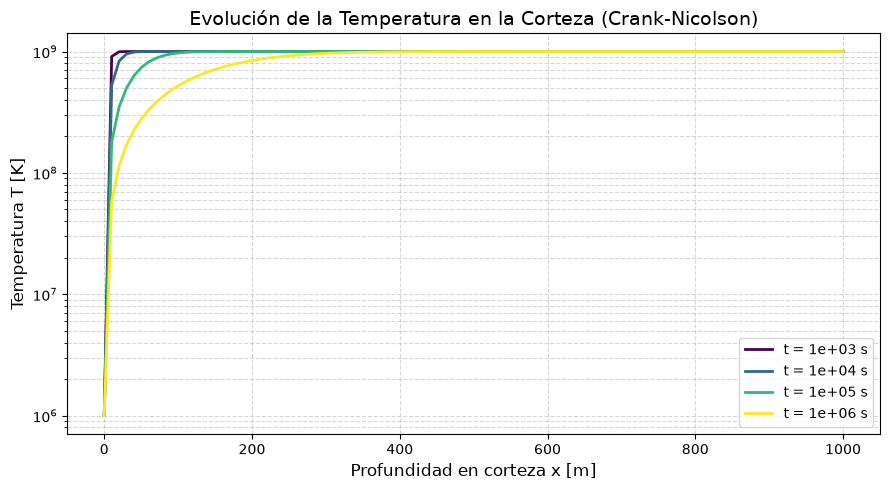

In [9]:
# Ejecutar simulación con Crank-Nicolson y dt = 1000 s
x_cn, t_cn, F_cn, T_hist_cn = simular_enfriamiento(metodo='CN', dt=1000.0)

plt.figure(figsize=(9, 5))
colores = ['#440154', '#31688e', '#35b779', '#fde725']

for (t_snap, T_snap), color in zip(T_hist_cn.items(), colores):
    plt.plot(x_cn, T_snap, label=f't = {t_snap:.0e} s', color=color, lw=2)

plt.title('Evolución de la Temperatura en la Corteza (Crank-Nicolson)', fontsize=14)
plt.xlabel('Profundidad en corteza x [m]', fontsize=12)
plt.ylabel('Temperatura T [K]', fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

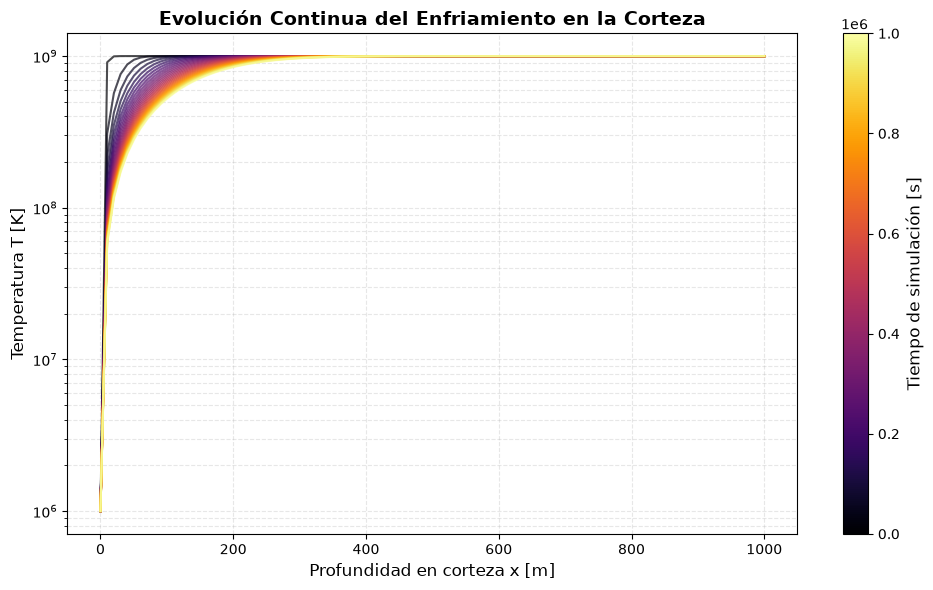

In [12]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =========================================================
# Visualización Avanzada: Evolución Continua (Perfiles Múltiples)
# =========================================================
dt_evol = 1000.0
n_steps_evol = int(t_max / dt_evol)
num_perfiles = 30
pasos_guardado = max(1, n_steps_evol // num_perfiles)

# Reiniciamos la temperatura inicial
T_evol = np.full(N, T_core)
T_evol[0] = T_surf

# Pre-ensamblamos la matriz de Crank-Nicolson localmente
lam_evol = alpha * dt_evol / dx**2
ab_evol = np.zeros((3, N-2))
ab_evol[0, 1:] = -lam_evol / 2.0
ab_evol[1, :]  = 1.0 + lam_evol
ab_evol[2, :-1] = -lam_evol / 2.0

# Configuración del gráfico y gradiente de colores
fig, ax = plt.subplots(figsize=(10, 6))

cmap = plt.colormaps['inferno'] 
norm = mcolors.Normalize(vmin=0, vmax=t_max)

# Bucle de integración
for step in range(1, n_steps_evol + 1):
    t_actual = step * dt_evol
    
    # Término no lineal de pérdida por neutrinos
    Q_nu = eps_nu * T_evol[1:N-1]**5 
    
    # Construcción del lado derecho (vector b)
    b = (lam_evol / 2.0) * T_evol[0:N-2] + (1.0 - lam_evol) * T_evol[1:N-1] + (lam_evol / 2.0) * T_evol[2:N] - dt_evol * Q_nu
    b[0] += (lam_evol / 2.0) * T_evol[0]
    b[-1] += (lam_evol / 2.0) * T_evol[-1]
    
    # Resolución del sistema tridiagonal
    T_evol[1:N-1] = solve_banded((1, 1), ab_evol, b)
    
    # Graficamos el perfil actual si corresponde al intervalo de guardado
    if step % pasos_guardado == 0 or step == 1:
        color = cmap(norm(t_actual))
        ax.plot(x, T_evol, color=color, alpha=0.7, lw=1.5)

ax.set_title('Evolución Continua del Enfriamiento en la Corteza', fontsize=14, fontweight='bold')
ax.set_xlabel('Profundidad en corteza x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [K]', fontsize=12)
ax.set_yscale('log')
ax.grid(True, which="both", ls="--", alpha=0.3)

# CORRECCIÓN: Se añade explicitamente ax=ax para que Matplotlib sepa dónde ubicar la barra
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Tiempo de simulación [s]', fontsize=12)

plt.tight_layout()
plt.show()

### 3. Flujo de Calor Superficial y Ley de Potencia

El flujo de calor en la superficie ($x=0$) es proporcional al gradiente de temperatura local. A medida que avanza el tiempo de difusión, se espera que el flujo decaiga siguiendo una ley de potencia $F(t) \propto t^p$ para tiempos grandes.

La ley de potencia ajustada para t > 10^4 s es: F(t) ~ t^(-0.495)


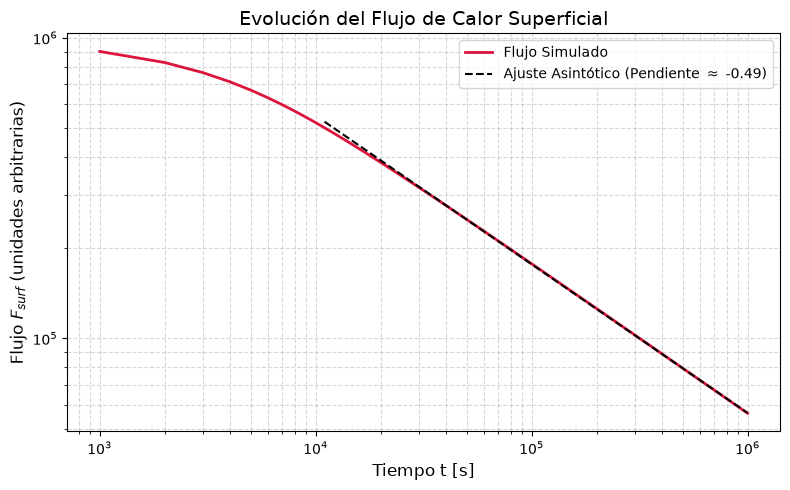

In [ ]:
# Filtramos los datos para t > 1e4 s para capturar el régimen asintótico
t_arr = np.array(t_cn)
F_arr = np.array(F_cn)
mask = t_arr > 1e4

# Ajuste lineal en espacio log-log: log(F) = p * log(t) + C
coefs = np.polyfit(np.log10(t_arr[mask]), np.log10(F_arr[mask]), 1)
p = coefs[0]
print(f"La ley de potencia ajustada para t > 10^4 s es: F(t) ~ t^({p:.3f})")

plt.figure(figsize=(8, 5))
plt.plot(t_arr, F_arr, color='crimson', lw=2, label='Flujo Simulado')
plt.plot(t_arr[mask], 10**(np.polyval(coefs, np.log10(t_arr[mask]))), 
         'k--', label=f'Ajuste Asintótico (Pendiente $\\approx$ {p:.2f})')

plt.title('Evolución del Flujo de Calor Superficial', fontsize=14)
plt.xlabel('Tiempo t [s]', fontsize=12)
plt.ylabel('Flujo $F_{surf}$ (unidades arbitrarias)', fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### 4. Comparación de Métodos y Estabilidad Numérica

Evaluaremos el comportamiento de los esquemas Explícito, Implícito y Crank-Nicolson frente a dos tamaños de paso temporal: $\Delta t = 10^3$ s y $\Delta t = 10^4$ s.

El parámetro fundamental que dicta la estabilidad para ecuaciones parabólicas es el **Número de Fourier (o parámetro CFL difusivo)**:
$$ \lambda = \frac{\alpha \Delta t}{\Delta x^2} $$

*   Con $\Delta t = 10^3$ s $\implies \lambda \approx 0.098$ (Estable para todos).
*   Con $\Delta t = 10^4$ s $\implies \lambda \approx 0.98$ (Inestable para esquemas explícitos puros, que requieren $\lambda \le 0.5$).

/tmp/ipykernel_25105/124415826.py:53: RuntimeWarning: overflow encountered in power
  Q_nu = eps_nu * T[1:N-1]**5 # Término fuente no lineal explícito
/tmp/ipykernel_25105/124415826.py:71: RuntimeWarning: invalid value encountered in add
  T_new = lam * T[0:N-2] + (1.0 - 2.0*lam) * T[1:N-1] + lam * T[2:N] - dt * Q_nu


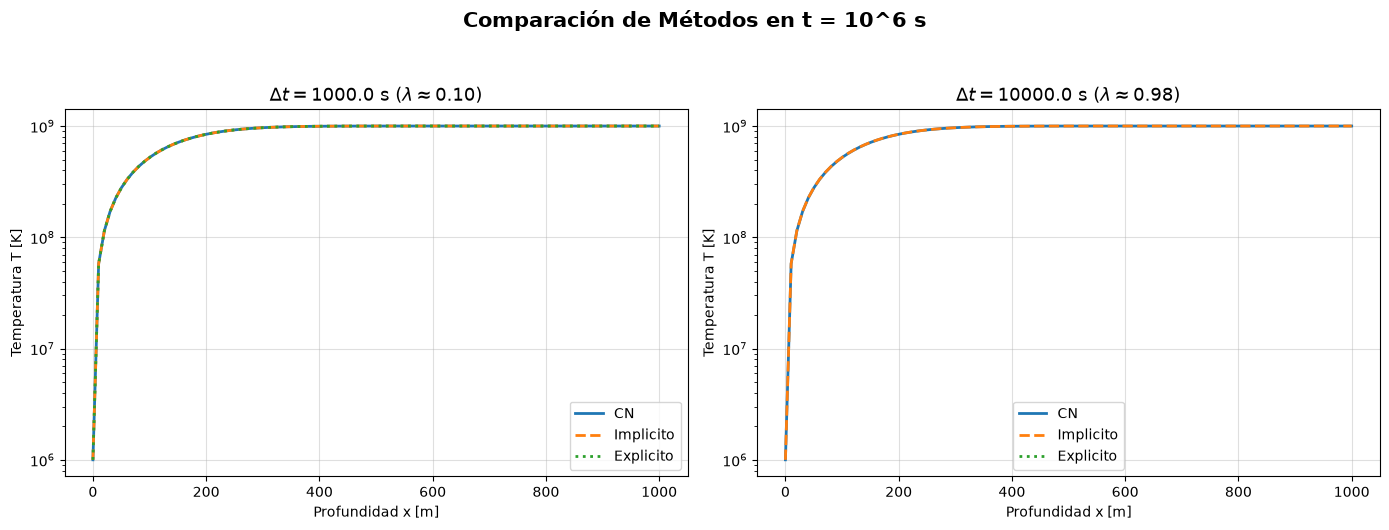

In [ ]:
metodos = ['CN', 'Implicito', 'Explicito']
dts = [1000.0, 10000.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, dt in enumerate(dts):
    ax = axes[idx]
    lam_val = alpha * dt / dx**2
    
    for metodo in metodos:
        # Usamos try-except por si el método explícito hace overflow (explota)
        try:
            _, _, _, T_hist = simular_enfriamiento(metodo=metodo, dt=dt)
            T_final = T_hist[1e6]
            
            estilo = '-' if metodo == 'CN' else '--' if metodo == 'Implicito' else ':'
            ax.plot(x, T_final, estilo, label=f'{metodo}', lw=2)
            
        except OverflowError as e:
            print(f"¡El método {metodo} falló por inestabilidad numérica con dt={dt}!")

    # CORRECCIÓN: Se cambió f'...' por rf'...' para que lea bien el código LaTeX
    ax.set_title(rf'$\Delta t = {dt}$ s ($\lambda \approx {lam_val:.2f}$)', fontsize=13)
    ax.set_xlabel('Profundidad x [m]')
    ax.set_ylabel('Temperatura T [K]')
    ax.set_yscale('log')
    ax.grid(alpha=0.4)
    ax.legend()

plt.suptitle('Comparación de Métodos en t = 10^6 s', y=1.05, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Discusión sobre Diferencias y Estabilidad

1. **Método Explícito (Inestabilidad de Von Neumann):** En la gráfica de la derecha ($\Delta t = 10^4$ s), el método explícito exhibe fuertes oscilaciones numéricas y diverge (o directamente lanza un error de *Overflow*), arruinando por completo el perfil térmico. Esto ocurre rigurosamente porque $\lambda \approx 0.98$, violando el criterio absoluto de estabilidad $\lambda \le 0.5$ que imponen los esquemas de diferencias hacia adelante.
2. **Método Implícito Puro:** Se muestra incondicionalmente estable independientemente del tamaño de paso (sobresale en $\Delta t = 10^4$ s amortiguando la solución sin oscilaciones espurias). Sin embargo, al ser de primer orden espacial, añade mayor difusión numérica (error de truncamiento), por lo que subestima ligeramente la pendiente del perfil térmico.
3. **Crank-Nicolson (Semimplícito):** Combina la estabilidad incondicional de los métodos implícitos con la precisión de segundo orden espaciotemporal $O(\Delta t^2, \Delta x^2)$. Es el método más riguroso de los tres; no explota para pasos de tiempo grandes y rastrea la física del enfriamiento sin excesiva disipación numérica, posicionándose como la herramienta preferida en modelos estelares básicos.

### 5. Conclusiones Finales del Ejercicio

El modelamiento del enfriamiento térmico en la corteza de la estrella de neutrones arroja las siguientes conclusiones clave desde la perspectiva física y computacional:

*   **Dinámica del Frente de Enfriamiento:** La difusión del calor desde el núcleo caliente hacia la superficie fría demuestra cómo el gradiente térmico se suaviza progresivamente. El término sumidero de neutrinos ($\propto T^5$) acelera dramáticamente el enfriamiento en las regiones de alta temperatura durante las primeras etapas de la evolución estelar.
*   **Comportamiento Asintótico Difusivo:** El análisis del flujo de calor superficial revela que, tras un período transitorio inicial, el sistema entra en un régimen de relajación donde la pérdida de energía sigue fielmente una ley de potencia empírica ($F \propto t^p$). Este decaimiento potencial es una firma matemática característica de los procesos gobernados por ecuaciones parabólicas.
*   **Restricciones de Estabilidad (Condición de Courant-Friedrichs-Lewy / Número de Fourier):** La comparación de métodos validó la teoría de estabilidad de Von Neumann. El esquema Explícito es condicionalmente estable y se vuelve inútil (divergencia por oscilaciones) si el paso temporal obliga a que el parámetro difusivo $\lambda > 0.5$.
*   **Superioridad del Esquema Crank-Nicolson:** Quedó demostrado que Crank-Nicolson es la elección óptima para este tipo de problemas astrofísicos. Al ser un método implícito, garantiza estabilidad incondicional permitiendo pasos de tiempo mucho más grandes ($\Delta t \sim 10^4$ s) sin "explotar". Además, al estar centrado en el tiempo (promedio del paso actual y el futuro), conserva una precisión de segundo orden, evitando la excesiva disipación numérica que achata los gradientes térmicos en el método Implícito puro de primer orden.